In [31]:
import pandas as pd
df = pd.read_csv("Student_performance_data _.csv")


In [32]:
df_clean = df.drop(columns=["StudentID"])


In [33]:
print(df_clean.isnull().sum())


Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64


In [34]:
print(df_clean.dtypes)


Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
GradeClass           float64
dtype: object


In [35]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
numerical_cols = ["Age", "StudyTimeWeekly", "Absences", "GPA"]
df_clean[numerical_cols] = scaler.fit_transform(df_clean[numerical_cols])


In [36]:
print(df_clean.head())


        Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  Absences  \
0  0.666667       1          0                  2         0.992773  0.241379   
1  1.000000       0          0                  1         0.771270  0.000000   
2  0.000000       0          2                  3         0.210718  0.896552   
3  0.666667       1          0                  3         0.501965  0.482759   
4  0.666667       1          0                  2         0.233840  0.586207   

   Tutoring  ParentalSupport  Extracurricular  Sports  Music  Volunteering  \
0         1                2                0       0      1             0   
1         0                1                0       0      0             0   
2         0                2                0       0      0             0   
3         0                3                1       0      0             0   
4         1                3                0       0      0             0   

        GPA  GradeClass  
0  0.732299         2.0 

C:\Users\yeewe\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(
C:\Users\yeewe\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(
C:\Users\yeewe\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(
C:\Users\yeewe\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Win

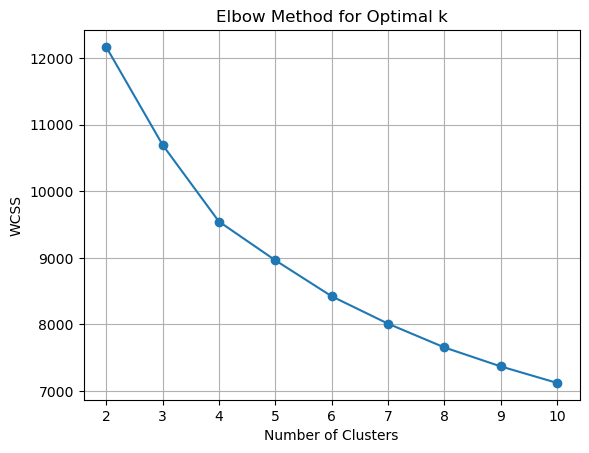

In [37]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_clean)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()


In [38]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(df_clean)


C:\Users\yeewe\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(


In [39]:
import os
os.environ["OMP_NUM_THREADS"] = "10"
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(df_clean)


C:\Users\yeewe\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(


In [49]:
print(df_clean[['KMeans_Cluster', 'Hierarchical_Cluster']].head())


KeyError: "None of [Index(['KMeans_Cluster', 'Hierarchical_Cluster'], dtype='object')] are in the [columns]"

In [51]:
# View a sample of the clustered data (after KMeans is applied)
df_clean[['Age', 'StudyTimeWeekly', 'GPA', 'Absences', 'Cluster']].head()


,Age,StudyTimeWeekly,GPA,Absences,Cluster
0,0.666667,0.992773,0.732299,0.241379,1
1,1.000000,0.771270,0.760729,0.000000,1
2,0.000000,0.210718,0.028151,0.896552,0
3,0.666667,0.501965,0.513555,0.482759,3
4,0.666667,0.233840,0.322015,0.586207,3


In [53]:
from sklearn.metrics import silhouette_score

# Calculate silhouette score for K-Means clustering
score = silhouette_score(df_clean.drop(columns=['Cluster']), df_clean['Cluster'])
print("Silhouette Score:", score)


Silhouette Score: 0.16789477975625128
